# Q1 · How often are power prices negative?

Day-ahead prices for 8 European bidding zones, 2019 → 2026 (year to date).
Reads the dbt mart `fct_negative_hours` from the DuckDB warehouse (`cd warehouse && uv run dbt build` first).

**Definitions** ([ADR-005](../control-room/04%20Decisions/ADR-005%20Negative%20Hours%20Metric.md)):
a **negative hour** is an hour whose hourly mean day-ahead price is below 0 €/MWh, the convention of published
counts (RTE, REE); before the 15-min switch on 1 Oct 2025 that is simply an hourly price below 0. The duration of
negative 15-min periods is kept as a secondary measure (`negative_period_hours`). Years are local calendar years.
Full years (2019 to 2025) are compared with full years; **2026 to date is only compared with the same window of
earlier years** (`fct_ytd_comparison`), never with a full year. Partial years (2026 to date; Poland 2019,
whose prices were in PLN before 20 Nov 2019) are flagged by `is_partial_year` / `partial_reason`.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

import chart_style as cs

cs.apply_style()

with duckdb.connect(str(cs.WAREHOUSE), read_only=True) as con:
    q1 = con.sql("select * from fct_negative_hours order by zone, local_year").df()
    as_of = con.sql("select as_of_date from int_as_of").fetchone()[0]
    ytd = con.sql("select * from fct_ytd_comparison order by zone, local_year").df()

def eur(v, decimals=0):
    # Format a price with a true minus sign.
    return f"{v:,.{decimals}f}".replace("-", "−")


# Every 2026 number runs to the run's as-of date (int_as_of), the same for all zones.
YTD_LABEL = f"1 Jan to {as_of:%-d %b} 2026"
WINDOW = f"1 Jan to {as_of:%-d %b}"
IT_NOTE = "North Italy: offers below 0 €/MWh are not allowed on its day-ahead market (GME), so prices cannot go negative."
CURRENT_YEAR = 2026
print("2026 year to date:", YTD_LABEL)
q1

2026 year to date: 1 Jan to 2 Oct 2026


,zone,local_year,negative_hours,zero_or_negative_hours,negative_period_hours,zero_or_negative_period_hours,covered_hours,expected_hours,completeness,min_price,avg_price,avg_price_negative_periods,is_partial_year,partial_reason,data_through_date
0,BE,2019,71.0,71.0,71.0,71.00,8759.0,8760.0,0.999886,-500.00,39.35,-52.68,False,NaN,2019-12-31
1,BE,2020,136.0,140.0,136.0,140.00,8784.0,8784.0,1.000000,-115.31,31.88,-18.66,False,NaN,2020-12-31
2,BE,2021,159.0,167.0,159.0,167.00,8760.0,8760.0,1.000000,-70.00,104.12,-19.07,False,NaN,2021-12-31
3,BE,2022,112.0,117.0,112.0,117.00,8760.0,8760.0,1.000000,-100.00,244.53,-27.66,False,NaN,2022-12-31
4,BE,2023,222.0,253.0,222.0,253.00,8760.0,8760.0,1.000000,-120.00,97.27,-10.45,False,NaN,2023-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,PT,2022,0.0,4.0,0.0,4.00,8760.0,8760.0,1.000000,0.00,167.87,NaN,False,NaN,2022-12-31
60,PT,2023,0.0,69.0,0.0,69.00,8760.0,8760.0,1.000000,0.00,88.28,NaN,False,NaN,2023-12-31
61,PT,2024,196.0,723.0,196.0,723.00,8784.0,8784.0,1.000000,-2.00,63.46,-0.26,False,NaN,2024-12-31
62,PT,2025,200.0,408.0,198.5,413.25,8760.0,8760.0,1.000000,-5.00,66.18,-0.97,False,NaN,2025-12-31


## Chart 1 · Negative hours per zone and year
Small multiples (one panel per zone) rather than 8 overlapping lines. Full years only (2019 to 2025); panels are
ordered by 2025. 2026 is not over, so it is compared like for like in the next chart. Poland 2019 is left out
(`pln_prices_excluded`).

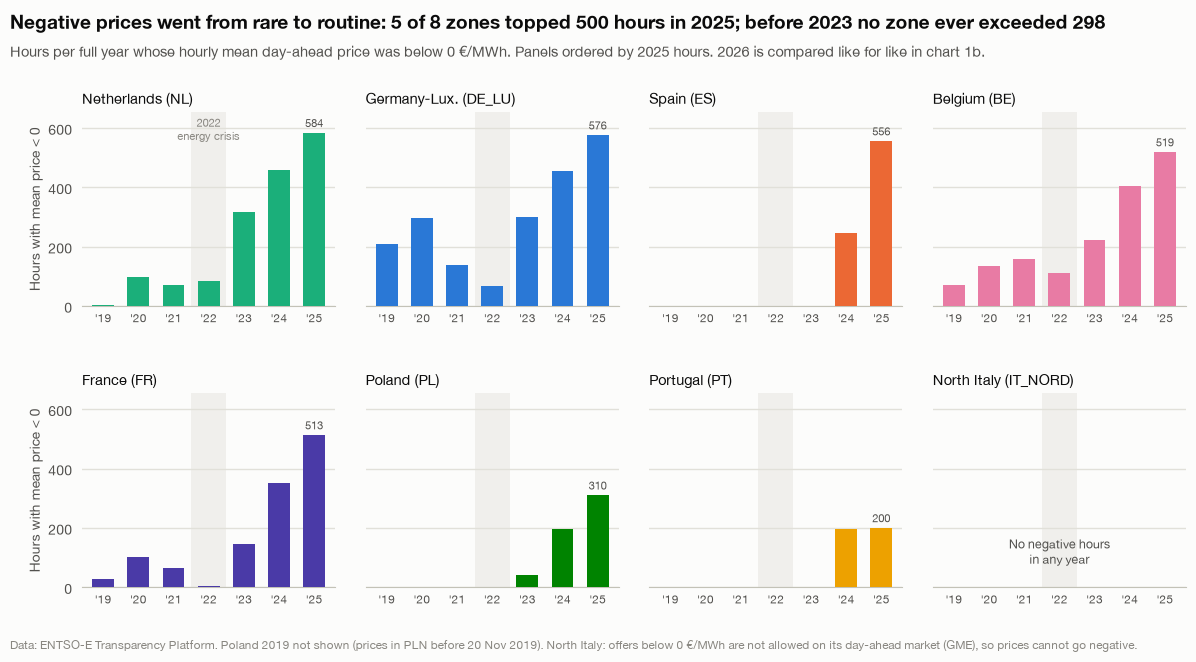

In [2]:
# Full years only.
c1 = q1[~q1.is_partial_year]
order = c1[c1.local_year == 2025].sort_values("negative_hours", ascending=False).zone.tolist()
years = list(range(2019, CURRENT_YEAR))
ymax = c1.negative_hours.max()

fig, axes = plt.subplots(2, 4, figsize=(12, 6.6), sharey=True)
fig.subplots_adjust(left=0.07, right=0.99, top=0.83, bottom=0.11, hspace=0.45, wspace=0.12)

for ax, zone in zip(axes.flat, order):
    color = cs.ZONE_COLORS[zone]
    z = c1[c1.zone == zone].set_index("local_year").reindex(years)
    ax.axvspan(2021.5, 2022.5, color=cs.HIGHLIGHT_BAND, zorder=0, lw=0)
    for year, hours in z.negative_hours.items():
        if pd.isna(hours) or hours == 0:
            continue
        ax.bar(year, hours, width=0.62, color=color, zorder=3)
    # Selective label: the last full year.
    for year in (2025,):
        hours = z.negative_hours.get(year)
        if pd.notna(hours) and hours > 0:
            ax.text(year, hours + ymax * 0.02, f"{hours:,.0f}", ha="center", va="bottom",
                    fontsize=8, color=cs.INK_SECONDARY)
    if z.negative_hours.fillna(0).max() == 0:
        ax.text(2022, ymax * 0.12, "No negative hours\nin any year", ha="center", va="bottom",
                fontsize=9, color=cs.INK_SECONDARY)
    ax.set_title(f"{cs.ZONE_LABELS[zone]} ({zone})", loc="left", fontsize=10.5, color=cs.INK, pad=6)
    ax.set_xticks(years, [f"'{y % 100:02d}" for y in years])
    ax.tick_params(axis="x", length=0, labelsize=8.5)
    ax.set_xlim(years[0] - 0.6, years[-1] + 0.6)  # same years in every panel
    ax.set_ylim(0, ymax * 1.12)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(200))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.spines["bottom"].set_color(cs.AXIS)

axes[0, 0].text(2022, ymax * 1.1, "2022\nenergy crisis", ha="center", va="top",
                fontsize=8, color=cs.INK_MUTED, linespacing=1.1)
for ax in axes[:, 0]:
    ax.set_ylabel("Hours with mean price < 0")

n_over_500 = (c1[c1.local_year == 2025].negative_hours > 500).sum()
before_2023 = c1[c1.local_year < 2023].negative_hours.max()
cs.add_title(
    fig,
    f"Negative prices went from rare to routine: {n_over_500} of 8 zones topped 500 hours in 2025; "
    f"before 2023 no zone ever exceeded {before_2023:,.0f}",
    "Hours per full year whose hourly mean day-ahead price was below 0 €/MWh. Panels ordered by 2025 hours. "
    "2026 is compared like for like in chart 1b.",
)
cs.add_source(fig, "Poland 2019 not shown (prices in PLN before 20 Nov 2019). " + IT_NOTE)
cs.save(fig, "q1_negative_hours_by_zone")
plt.show()

## Chart 1b · 2026 to date vs the same window of 2025
Like for like: both years cut to the same dates (1 January to the as-of date). One row per zone: 2025 (ring) and
2026 (dot), with the change in hours.

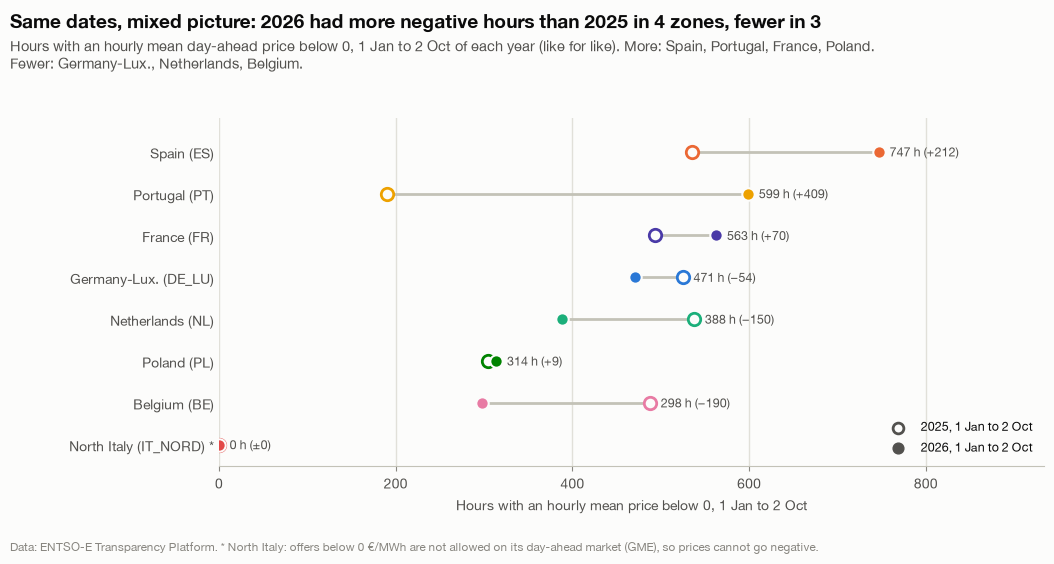

In [3]:
c1b = ytd[ytd.local_year.isin([2025, CURRENT_YEAR])].pivot(index="zone", columns="local_year", values="negative_hours")
c1b = c1b.sort_values(CURRENT_YEAR, ascending=False)
up = [z for z in c1b.index if c1b.loc[z, CURRENT_YEAR] > c1b.loc[z, 2025]]
down = [z for z in c1b.index if c1b.loc[z, CURRENT_YEAR] < c1b.loc[z, 2025]]

fig, ax = plt.subplots(figsize=(11, 5.6))
fig.subplots_adjust(left=0.2, right=0.95, top=0.79, bottom=0.17)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
for i, (zone, r) in enumerate(c1b.iterrows()):
    color = cs.ZONE_COLORS[zone]
    a, b = r[2025], r[CURRENT_YEAR]
    ax.plot([a, b], [i, i], color=cs.AXIS, lw=2, zorder=1)
    ax.scatter(a, i, s=80, facecolor=cs.SURFACE, edgecolor=color, linewidth=2, zorder=3)
    ax.scatter(b, i, s=80, color=color, edgecolor=cs.SURFACE, linewidth=1.5, zorder=3)
    change = b - a
    sign = "+" if change > 0 else ("\u2212" if change < 0 else "\u00b1")
    ax.text(max(a, b) + 12, i, f"{b:,.0f} h ({sign}{abs(change):,.0f})", ha="left", va="center",
            fontsize=9, color=cs.INK_SECONDARY)
ax.set_yticks(range(len(c1b)), [f"{cs.ZONE_LABELS[z]} ({z})" + (" *" if z == "IT_NORD" else "") for z in c1b.index])
ax.set_ylim(len(c1b) - 0.5, -0.8)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.set_xlim(0, c1b.max().max() * 1.25)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel(f"Hours with an hourly mean price below 0, {WINDOW}")
ax.spines["bottom"].set_color(cs.AXIS)
ax.scatter([], [], s=60, facecolor=cs.SURFACE, edgecolor=cs.INK_SECONDARY, linewidth=2, label=f"2025, {WINDOW}")
ax.scatter([], [], s=60, color=cs.INK_SECONDARY, label=f"2026, {WINDOW}")
ax.legend(loc="lower right", frameon=False, fontsize=9)

names = lambda zs: ", ".join(cs.ZONE_LABELS[z] for z in zs)
cs.add_title(
    fig,
    f"Same dates, mixed picture: 2026 had more negative hours than 2025 in {len(up)} zones, fewer in {len(down)}",
    f"Hours with an hourly mean day-ahead price below 0, {WINDOW} of each year (like for like). "
    f"More: {names(up)}.\nFewer: {names(down)}.",
)
cs.add_source(fig, "* " + IT_NOTE)
cs.save(fig, "q1_ytd_like_for_like")
plt.show()

## Chart 2 · Frequency vs depth (2025)
How often prices went negative (x) against how far below zero they went on average (y), one point per zone.
Labels add the lowest price of the year. North Italy is left out: it had no negative hours.

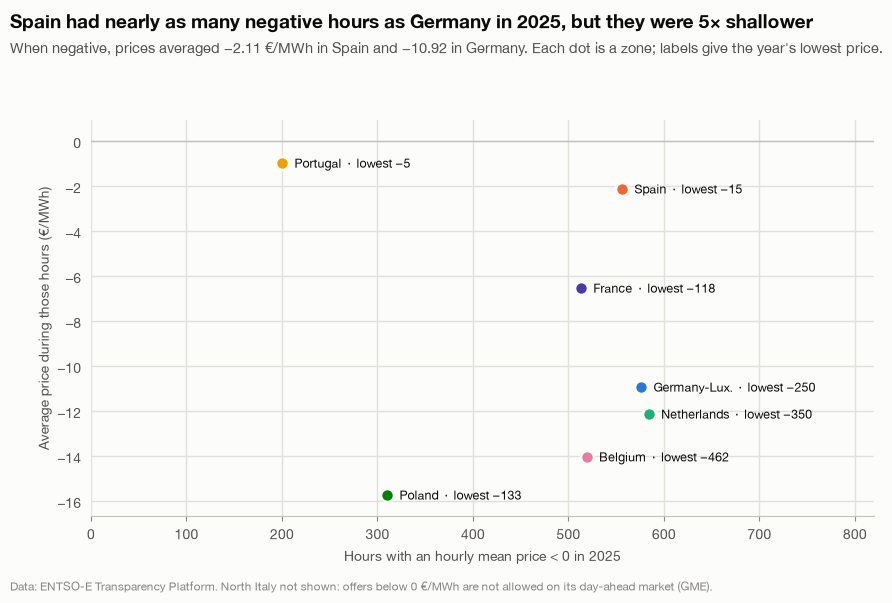

In [4]:
c2 = q1[(q1.local_year == 2025) & (q1.negative_hours > 0)].copy()

fig, ax = plt.subplots(figsize=(9, 6))
fig.subplots_adjust(left=0.1, right=0.97, top=0.80, bottom=0.14)
ax.grid(axis="x", color=cs.GRID, lw=1)
ax.axhline(0, color=cs.AXIS, lw=1, zorder=1)
dots = {}
for r in c2.itertuples():
    ax.scatter(r.negative_hours, r.avg_price_negative_periods, s=90, color=cs.ZONE_COLORS[r.zone],
               edgecolor=cs.SURFACE, linewidth=2, zorder=3)
    dots[r.zone] = (r.negative_hours, r.avg_price_negative_periods)

# Every label sits just right of its own dot, at the dot's height.
labels = {}
for r in c2.itertuples():
    labels[r.zone] = ax.annotate(
        f"{cs.ZONE_LABELS[r.zone]}  ·  lowest {eur(r.min_price)}",
        dots[r.zone], xytext=(9, 0), textcoords="offset points",
        ha="left", va="center", fontsize=9, color=cs.INK)

ax.set_xlim(0, 820)
y_lo, y_hi = c2.avg_price_negative_periods.min(), 0  # data range, plus the zero line
pad = (y_hi - y_lo) * 0.06
ax.set_ylim(y_lo - pad, y_hi + pad)
ax.set_xlabel("Hours with an hourly mean price < 0 in 2025")
ax.set_ylabel("Average price during those hours (€/MWh)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

# Check: each label's nearest dot (in screen space) is its own zone's dot.
fig.canvas.draw()
to_px = ax.transData.transform
for zone, text in labels.items():
    box = text.get_window_extent()
    left_mid = (box.x0, (box.y0 + box.y1) / 2)
    nearest = min(dots, key=lambda z: (to_px(dots[z])[0] - left_mid[0]) ** 2 + (to_px(dots[z])[1] - left_mid[1]) ** 2)
    assert nearest == zone, f"label {zone} is closest to {nearest}"
    for other, xy in dots.items():  # and no label covers another zone's dot
        assert other == zone or not box.contains(*to_px(xy)), f"label {zone} covers {other}"

es = c2.set_index("zone").loc["ES"]
de = c2.set_index("zone").loc["DE_LU"]
cs.add_title(
    fig,
    f"Spain had nearly as many negative hours as Germany in 2025, but they were {de.avg_price_negative_periods / es.avg_price_negative_periods:.0f}× shallower",
    f"When negative, prices averaged {eur(es.avg_price_negative_periods, 2)} €/MWh in Spain and "
    f"{eur(de.avg_price_negative_periods, 2)} in Germany. Each dot is a zone; labels give the year's lowest price.",
)
cs.add_source(fig, "North Italy not shown: offers below 0 €/MWh are not allowed on its day-ahead market (GME).")
cs.save(fig, "q1_frequency_vs_depth_2025")
plt.show()

## Chart 3 · Time at or below zero, 2026 to date: below 0 vs exactly 0
Each bar is a zone's share of time with a price ≤ 0, split into truly negative (solid) and exactly 0 €/MWh (light tint
of the same colour). Measured on individual price periods (a 15-min period counts 0.25 h), not hourly means: whether a
price is exactly zero is a property of each cleared price, which averaging to the hour would hide. North Italy is
drawn in neutral grey: its only prices at or below zero are exactly 0. A 2026 share covers the sunny half of the
year more than the winter, so it is not comparable with a full year's share.

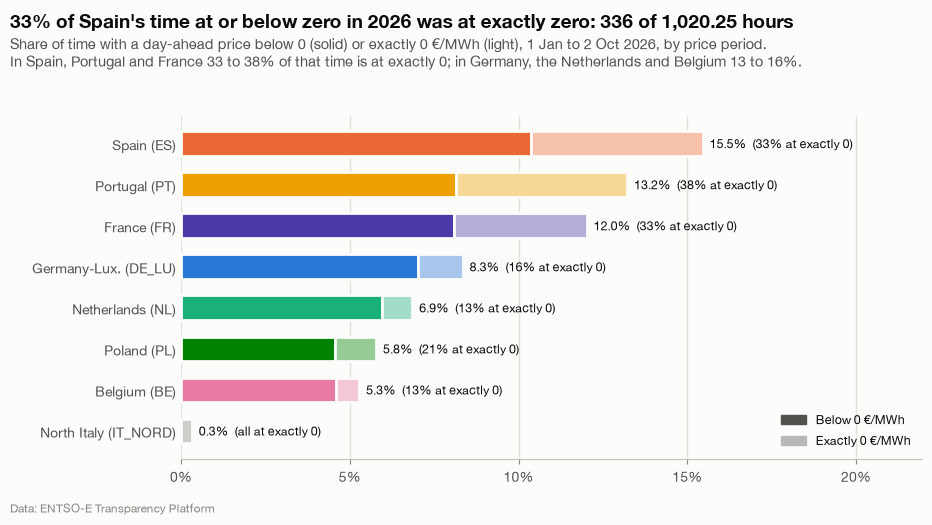

In [5]:
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch


def tint(color, amount=0.6):
    # Mix a colour with the chart surface: amount = how far towards the surface.
    c, s = to_rgb(color), to_rgb(cs.SURFACE)
    return tuple(ci + (si - ci) * amount for ci, si in zip(c, s))


c3 = q1[q1.local_year == CURRENT_YEAR].assign(
    below=lambda d: d.negative_period_hours / d.covered_hours,
    exactly_zero=lambda d: (d.zero_or_negative_period_hours - d.negative_period_hours) / d.covered_hours,
    total=lambda d: d.zero_or_negative_period_hours / d.covered_hours,
    zero_part=lambda d: (d.zero_or_negative_period_hours - d.negative_period_hours) / d.zero_or_negative_period_hours,
).sort_values("total")

colors = {z: (cs.INK_MUTED if z == "IT_NORD" else cs.ZONE_COLORS[z]) for z in c3.zone}
fig, ax = plt.subplots(figsize=(9.5, 5.2))
fig.subplots_adjust(left=0.19, right=0.97, top=0.78, bottom=0.12)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
names = [f"{cs.ZONE_LABELS[z]} ({z})" for z in c3.zone]
# 2px surface-coloured edges give the gap between the two segments.
ax.barh(names, c3.below, height=0.6, color=[colors[z] for z in c3.zone],
        edgecolor=cs.SURFACE, linewidth=2, zorder=3)
ax.barh(names, c3.exactly_zero, left=c3.below, height=0.6, color=[tint(colors[z]) for z in c3.zone],
        edgecolor=cs.SURFACE, linewidth=2, zorder=3)
for i, r in enumerate(c3.itertuples()):
    note = "all at exactly 0" if r.below == 0 else f"{r.zero_part:.0%} at exactly 0"
    ax.text(r.total + 0.002, i, f"{r.total:.1%}  ({note})", va="center", ha="left",
            fontsize=9, color=cs.INK)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_xlim(0, c3.total.max() * 1.42)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.spines["bottom"].set_color(cs.AXIS)
ax.legend(handles=[Patch(color=cs.INK_SECONDARY, label="Below 0 €/MWh"),
                   Patch(color=tint(cs.INK_SECONDARY), label="Exactly 0 €/MWh")],
          loc="lower right", frameon=False, fontsize=9)

es = c3.set_index("zone").loc["ES"]
es_zero_h = es.zero_or_negative_period_hours - es.negative_period_hours
high = c3[c3.zone.isin(["ES", "PT", "FR"])].zero_part
low = c3[c3.zone.isin(["DE_LU", "NL", "BE"])].zero_part
cs.add_title(
    fig,
    f"{es.zero_part:.0%} of Spain's time at or below zero in 2026 was at exactly zero: "
    f"{es_zero_h:,.0f} of {es.zero_or_negative_period_hours:,.2f} hours",
    f"Share of time with a day-ahead price below 0 (solid) or exactly 0 €/MWh (light), {YTD_LABEL}, by price period.\n"
    f"In Spain, Portugal and France {high.min() * 100:.0f} to {high.max():.0%} of that time is at exactly 0; "
    f"in Germany, the Netherlands and Belgium {low.min() * 100:.0f} to {low.max():.0%}.",
)
cs.add_source(fig)
cs.save(fig, "q1_share_at_or_below_zero_2026")
plt.show()

## Numbers quoted in the findings

In [6]:
cols = ["zone", "local_year", "negative_hours", "zero_or_negative_hours", "negative_period_hours",
        "zero_or_negative_period_hours", "covered_hours", "avg_price_negative_periods", "min_price",
        "is_partial_year", "partial_reason"]
q1[q1.local_year.isin([2022, 2025, 2026])][cols].sort_values(["local_year", "zone"])

,zone,local_year,negative_hours,zero_or_negative_hours,negative_period_hours,zero_or_negative_period_hours,covered_hours,avg_price_negative_periods,min_price,is_partial_year,partial_reason
3,BE,2022,112.0,117.0,112.00,117.00,8760.0,-27.66,-100.00,False,NaN
11,DE_LU,2022,69.0,75.0,69.00,75.00,8760.0,-2.08,-19.04,False,NaN
19,ES,2022,0.0,3.0,0.00,3.00,8760.0,NaN,0.00,False,NaN
27,FR,2022,4.0,8.0,4.00,8.00,8760.0,-0.68,-1.44,False,NaN
35,IT_NORD,2022,0.0,0.0,0.00,0.00,8760.0,NaN,10.00,False,NaN
43,NL,2022,85.0,110.0,85.00,110.00,8760.0,-34.61,-222.36,False,NaN
51,PL,2022,0.0,0.0,0.00,0.00,8760.0,NaN,16.33,False,NaN
59,PT,2022,0.0,4.0,0.00,4.00,8760.0,NaN,0.00,False,NaN
6,BE,2025,519.0,575.0,520.25,577.00,8760.0,-14.03,-462.33,False,NaN
14,DE_LU,2025,576.0,654.0,574.75,661.50,8760.0,-10.92,-250.32,False,NaN


In [7]:
ytd[ytd.local_year >= 2024][["zone", "local_year", "window_end_date", "negative_hours", "zero_or_negative_hours"]]

,zone,local_year,window_end_date,negative_hours,zero_or_negative_hours
5,BE,2024,2024-10-02,384.0,434.0
6,BE,2025,2025-10-02,488.0,544.0
7,BE,2026,2026-10-02,298.0,308.0
13,DE_LU,2024,2024-10-02,413.0,469.0
14,DE_LU,2025,2025-10-02,525.0,603.0
15,DE_LU,2026,2026-10-02,471.0,484.0
21,ES,2024,2024-10-02,242.0,769.0
22,ES,2025,2025-10-02,535.0,760.0
23,ES,2026,2026-10-02,747.0,907.0
29,FR,2024,2024-10-02,339.0,524.0


## Spain and Portugal in 2025, and Spain's first quarter of 2026
Two checks quoted in the findings, saved next to the mart CSVs: how often Spanish and Portuguese prices differed each
month of 2025 (the May split after the 28 April blackout), and Spain's January to March counts under each definition
(to compare with published figures).

In [8]:
with duckdb.connect(str(cs.WAREHOUSE), read_only=True) as con:
    es_pt = con.sql('''
        with es as (select hour_utc, hourly_mean_price p, hours, local_date from int_prices_hourly where zone = 'ES'),
             pt as (select hour_utc, hourly_mean_price p from int_prices_hourly where zone = 'PT')
        select month(es.local_date) as month,
               sum(es.hours) filter (where es.p < 0) as es_negative_hours,
               sum(es.hours) filter (where pt.p < 0) as pt_negative_hours,
               sum(es.hours) filter (where es.p <> pt.p) as hours_prices_differ
        from es join pt using (hour_utc)
        where year(es.local_date) = 2025
        group by month order by month''').df().fillna(0)
    es_q1 = con.sql('''
        select local_year,
               (select sum(hours) filter (where hourly_mean_price < 0) from int_prices_hourly h
                where h.zone = 'ES' and h.local_year = y.local_year and month(h.local_date) <= 3) as hourly_mean_below_0,
               (select sum(hours) filter (where hourly_mean_price <= 0) from int_prices_hourly h
                where h.zone = 'ES' and h.local_year = y.local_year and month(h.local_date) <= 3) as hourly_mean_at_or_below_0,
               (select sum(duration_h) filter (where price_eur_mwh < 0) from int_prices_local p
                where p.zone = 'ES' and p.local_year = y.local_year and month(p.local_date) <= 3) as periods_below_0,
               (select sum(duration_h) filter (where price_eur_mwh <= 0) from int_prices_local p
                where p.zone = 'ES' and p.local_year = y.local_year and month(p.local_date) <= 3) as periods_at_or_below_0
        from (select unnest([2025, 2026]) as local_year) y''').df()
es_pt.to_csv(cs.REPO_ROOT / "analysis" / "outputs" / "q1_es_pt_2025_monthly.csv", index=False)
es_q1.to_csv(cs.REPO_ROOT / "analysis" / "outputs" / "q1_es_jan_to_mar.csv", index=False)
display(es_pt)
es_q1

,month,es_negative_hours,pt_negative_hours,hours_prices_differ
0,1,0.0,0.0,42.0
1,2,0.0,0.0,6.0
2,3,48.0,21.0,60.0
3,4,117.0,104.0,72.0
4,5,239.0,4.0,389.0
5,6,55.0,10.0,136.0
6,7,13.0,13.0,9.0
7,8,31.0,24.0,44.0
8,9,32.0,14.0,51.0
9,10,16.0,10.0,91.0


,local_year,hourly_mean_below_0,hourly_mean_at_or_below_0,periods_below_0,periods_at_or_below_0
0,2025,48.0,73.0,48.0,73.0
1,2026,290.0,347.0,264.0,389.0


## Check: no en or em dashes in chart text
House style: ranges use "to", negative numbers use the real minus sign (U+2212). Matplotlib writes every
text string into the SVG as a comment next to its glyph outlines, so the exported files can be checked directly.

In [9]:
DASHES = {"\u2013": "en dash", "\u2014": "em dash"}
svgs = sorted(cs.FIGURES.glob("q1_*.svg"))
assert len(svgs) == 4, svgs
for svg in svgs:
    text = svg.read_text(encoding="utf-8")
    found = [name for char, name in DASHES.items() if char in text]
    assert not found, f"{svg.name} contains: {', '.join(found)}"
print(f"OK: no en/em dashes in {len(svgs)} SVGs:", ", ".join(s.name for s in svgs))

OK: no en/em dashes in 4 SVGs: q1_frequency_vs_depth_2025.svg, q1_negative_hours_by_zone.svg, q1_share_at_or_below_zero_2026.svg, q1_ytd_like_for_like.svg
